In [1]:
import os
import glob
import xml.etree.ElementTree as ET
import pandas as pd
from IPython.display import display

def analyze_dataset(dataset_dir):
    splits = ['train', 'valid', 'test'] 
    stats = {split: {'images': 0, 'objects': 0, 'classes': {}} for split in splits}
    
    for split in splits:
        split_path = os.path.join(dataset_dir, split)
        if not os.path.exists(split_path):
            continue 
            
        xml_files = glob.glob(os.path.join(split_path, '*.xml'))
        if not xml_files:
            xml_files = glob.glob(os.path.join(split_path, 'labels', '*.xml')) 
            
        stats[split]['images'] = len(xml_files)
        
        for xml_file in xml_files:
            tree = ET.parse(xml_file)
            root = tree.getroot()
            objects = root.findall('object')
            stats[split]['objects'] += len(objects)
            
            for obj in objects:
                cls_name = obj.find('name').text
                if cls_name not in stats[split]['classes']:
                    stats[split]['classes'][cls_name] = 0
                stats[split]['classes'][cls_name] += 1

    # In Tổng quan bằng text bình thường
    print("=" * 60)
    print("TỔNG QUAN DATASET")
    for split in splits:
        if stats[split]['images'] > 0:
            print(f"Số lượng ảnh {split.capitalize():<6}: {stats[split]['images']} (Chứa {stats[split]['objects']} vật thể)")
    print("=" * 60)
    
    all_classes = set()
    for split in splits:
        all_classes = all_classes.union(set(stats[split]['classes'].keys()))
    
    # Gom dữ liệu vào một List để đưa cho Pandas
    table_data = []
    for cls in sorted(all_classes):
        train_count = stats['train']['classes'].get(cls, 0)
        valid_count = stats['valid']['classes'].get(cls, 0)
        test_count = stats['test']['classes'].get(cls, 0)
        
        total = train_count + valid_count + test_count
        train_pct = (train_count / total * 100) if total > 0 else 0
        
        table_data.append({
            "Tên bệnh": cls,
            "Train": train_count,
            "Valid": valid_count,
            "Test": test_count,
            "Total": total,
            "Train_Percentage (%)": round(train_pct, 1)
        })
        
    # Tạo DataFrame và hiển thị bảng đẹp mắt
    df = pd.DataFrame(table_data)
    
    # Đặt Tên bệnh làm cột index để căn lề tự động đẹp hơn
    df.set_index("Tên bệnh", inplace=True)
    
    # Display sẽ render ra bảng HTML xịn xò trên Colab
    display(df)

# Gọi hàm thực thi
analyze_dataset('./Data')

TỔNG QUAN DATASET
Số lượng ảnh Train : 716 (Chứa 734 vật thể)
Số lượng ảnh Valid : 210 (Chứa 212 vật thể)
Số lượng ảnh Test  : 100 (Chứa 102 vật thể)


,Train,Valid,Test,Total,Train_Percentage (%)
Tên bệnh,,,,,
actinic keratosis,82,24,10,116,70.7
basal cell carcinoma,78,33,14,125,62.4
dermatofibroma,60,24,11,95,63.2
melanoma,67,34,16,117,57.3
nevus,80,24,9,113,70.8
pigmented benign keratosis,129,7,6,142,90.8
seborrheic keratosis,51,16,10,77,66.2
squamous cell carcinoma,96,28,11,135,71.1
vascular lesion,91,22,15,128,71.1


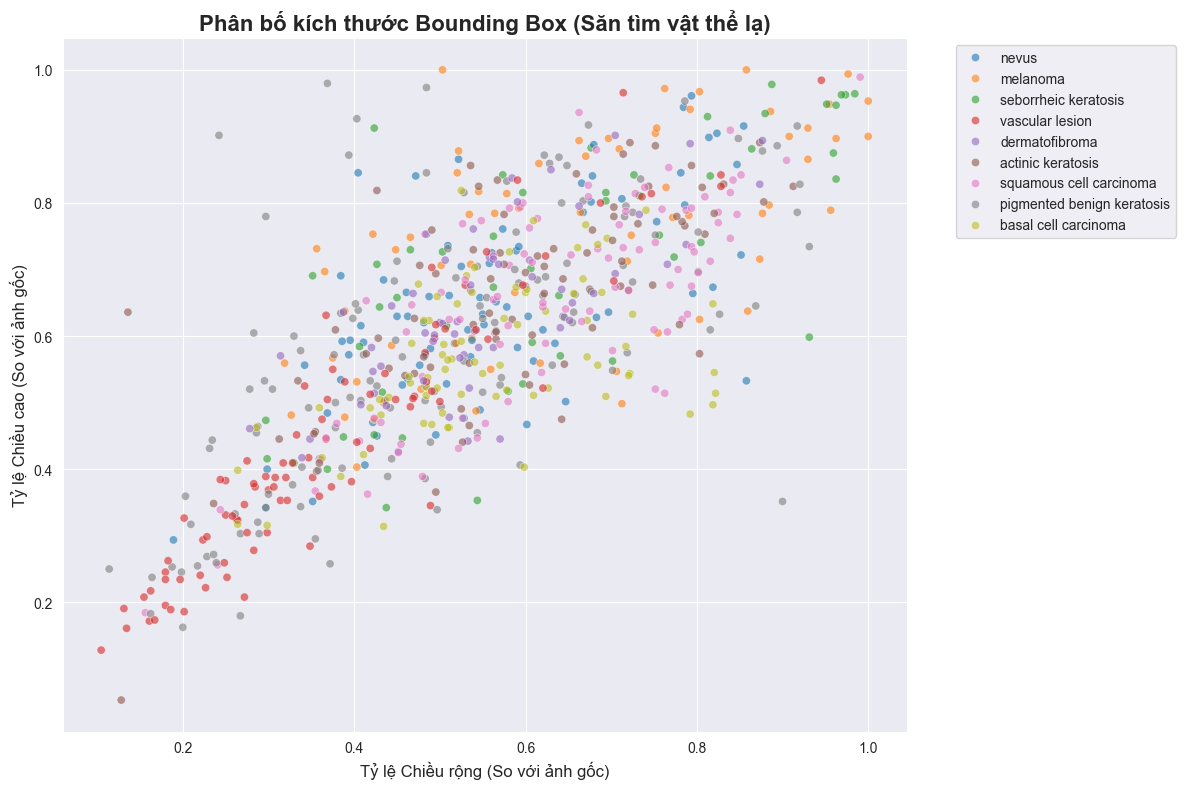


🚨 CẢNH BÁO CÁC VẬT THỂ CÓ NGUY CƠ LỖI (Quá to, quá nhỏ, mỏng dính):
-> Phát hiện 25 khung có kích thước dị dạng:


,Class,Width_Ratio,Height_Ratio
69,melanoma,0.857812,1.000000
91,melanoma,0.762500,0.971875
93,melanoma,0.962500,0.896875
97,melanoma,1.000000,0.900000
100,melanoma,0.503125,1.000000
104,melanoma,1.000000,0.953125
109,melanoma,0.803125,0.967187
111,melanoma,0.976562,0.993750
115,melanoma,0.954688,0.948438
134,melanoma,0.956250,0.789062


In [2]:
import os
import glob
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def check_weird_objects(dataset_dir):
    # Chỉ cần quét tập train là đủ để đánh giá
    train_path = os.path.join(dataset_dir, 'train')
    xml_files = glob.glob(os.path.join(train_path, '*.xml'))
    if not xml_files:
        xml_files = glob.glob(os.path.join(train_path, 'labels', '*.xml'))
        
    data = []
    
    for xml_file in xml_files:
        tree = ET.parse(xml_file)
        root = tree.getroot()
        
        # Lấy kích thước ảnh gốc để quy đổi tỷ lệ phần trăm (đỡ bị nhiễu nếu ảnh to nhỏ khác nhau)
        size = root.find('size')
        if size is not None:
            img_w = float(size.find('width').text)
            img_h = float(size.find('height').text)
        else:
            img_w, img_h = 640.0, 640.0 # Mặc định nếu file XML thiếu thẻ size
            
        for obj in root.findall('object'):
            cls_name = obj.find('name').text
            bndbox = obj.find('bndbox')
            
            xmin = float(bndbox.find('xmin').text)
            ymin = float(bndbox.find('ymin').text)
            xmax = float(bndbox.find('xmax').text)
            ymax = float(bndbox.find('ymax').text)
            
            # Tính chiều rộng và chiều cao của khung (quy ra phần trăm % so với ảnh gốc)
            box_width = (xmax - xmin) / img_w
            box_height = (ymax - ymin) / img_h
            
            data.append({
                'Class': cls_name,
                'Width_Ratio': box_width,
                'Height_Ratio': box_height
            })
            
    df = pd.DataFrame(data)
    
    # --- VẼ BIỂU ĐỒ SCATTER PLOT ---
    plt.figure(figsize=(12, 8))
    sns.set_style("darkgrid")
    
    # Vẽ các điểm, mỗi màu là một loại bệnh
    sns.scatterplot(data=df, x='Width_Ratio', y='Height_Ratio', hue='Class', alpha=0.6, palette='tab10')
    
    plt.title('Phân bố kích thước Bounding Box (Săn tìm vật thể lạ)', fontsize=16, fontweight='bold')
    plt.xlabel('Tỷ lệ Chiều rộng (So với ảnh gốc)', fontsize=12)
    # plt.xlabel('Tỷ lệ Chiều rộng (So với ảnh gốc)', fontsize=12)
    plt.ylabel('Tỷ lệ Chiều cao (So với ảnh gốc)', fontsize=12)
    
    # Căn chỉnh lại chú thích (Legend) ra ngoài cho khỏi che mất biểu đồ
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    
    # --- TÌM VÀ IN RA CÁC VẬT THỂ DỊ DẠNG ---
    print("\n🚨 CẢNH BÁO CÁC VẬT THỂ CÓ NGUY CƠ LỖI (Quá to, quá nhỏ, mỏng dính):")
    # Điều kiện lọc: Rộng/Cao < 1% (Quá nhỏ) hoặc Rộng/Cao > 95% (Toán màn hình)
    weird_boxes = df[(df['Width_Ratio'] < 0.01) | (df['Height_Ratio'] < 0.01) | 
                     (df['Width_Ratio'] > 0.95) | (df['Height_Ratio'] > 0.95)]
    
    if weird_boxes.empty:
        print("-> Tuyệt vời! Không phát hiện vật thể nào có kích thước bất thường.")
    else:
        print(f"-> Phát hiện {len(weird_boxes)} khung có kích thước dị dạng:")
        display(weird_boxes.head(10)) # Hiển thị thử 10 ca đầu tiên

# (Nhớ đổi lại đường dẫn nếu bạn đang lưu ở file khác nhé)
check_weird_objects('./Data')

In [3]:
import os
import glob
import torch
import cv2
import xml.etree.ElementTree as ET
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.optim as optim

# ==========================================
# 1. CẤU HÌNH ĐƯỜNG DẪN & THÔNG SỐ LOCAL
# ==========================================
# Đảm bảo bạn có thư mục Data/train nằm cùng cấp với file code này
DATA_DIR = './Data/train' 
SAVE_DIR = './checkpoints' # Code sẽ tự tạo thư mục này để lưu model
NUM_EPOCHS = 20

# Nếu máy bạn có card rời (VRAM >= 8GB) thì để 4, yếu hơn thì hạ xuống 2
BATCH_SIZE = 2 

classes_dict = {
    'actinic keratosis': 1,
    'basal cell carcinoma': 2,
    'dermatofibroma': 3,
    'melanoma': 4,
    'nevus': 5,
    'pigmented benign keratosis': 6,
    'seborrheic keratosis': 7,
    'squamous cell carcinoma': 8,
    'vascular lesion': 9
}
NUM_CLASSES = 10 # 9 bệnh + 1 Nền (Background)

os.makedirs(SAVE_DIR, exist_ok=True)

# ==========================================
# 2. XÂY DỰNG DATASET
# ==========================================
transform = transforms.Compose([transforms.ToTensor()])

class SkinCancerDataset(Dataset):
    def __init__(self, data_dir, classes_dict, transform=None):
        self.data_dir = data_dir
        self.classes_dict = classes_dict
        self.transform = transform
        
        search_path = os.path.join(data_dir, '*.jpg')
        self.image_paths = glob.glob(search_path)
        if not self.image_paths:
            self.image_paths = glob.glob(os.path.join(data_dir, 'images', '*.jpg'))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        xml_path = img_path.replace('.jpg', '.xml').replace('images', 'labels')
        if not os.path.exists(xml_path):
            xml_path = img_path.replace('.jpg', '.xml')

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        tree = ET.parse(xml_path)
        root = tree.getroot()
        
        boxes = []
        labels = []
        
        for member in root.findall('object'):
            label_name = member.find('name').text
            label_id = self.classes_dict.get(label_name, 0) 
            labels.append(label_id)
            
            bndbox = member.find('bndbox')
            xmin = float(bndbox.find('xmin').text)
            ymin = float(bndbox.find('ymin').text)
            xmax = float(bndbox.find('xmax').text)
            ymax = float(bndbox.find('ymax').text)
            
            # Vá lỗi khung bị xẹp
            if xmax <= xmin: xmax = xmin + 1.0
            if ymax <= ymin: ymax = ymin + 1.0

            boxes.append([xmin, ymin, xmax, ymax])
        
        # Vá lỗi ảnh rỗng
        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
        
        target = {}
        target["boxes"] = boxes
        target["labels"] = labels
        
        if self.transform:
            img = self.transform(img)
            
        return img, target

def collate_fn(batch):
    return tuple(zip(*batch))

# ==========================================
# 3. KHỞI TẠO MODEL FASTER R-CNN
# ==========================================
def get_model(num_classes):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

# ==========================================
# 4. HÀM MAIN THỰC THI (QUAN TRỌNG TRÊN LOCAL)
# ==========================================
def main():
    # Kiểm tra xem máy có cài đặt CUDA (NVIDIA GPU) chưa
    device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
    print(f"--- ĐANG SỬ DỤNG THIẾT BỊ: {device.type.upper()} ---")
    if device.type == 'cpu':
        print("⚠️ CẢNH BÁO: Bạn đang chạy bằng CPU, tốc độ sẽ rất chậm!")

    train_dataset = SkinCancerDataset(data_dir=DATA_DIR, classes_dict=classes_dict, transform=transform)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)

    model = get_model(NUM_CLASSES)
    model.to(device)

    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.Adam(params, lr=0.0001, weight_decay=0.0005)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

    print(f"--- BẮT ĐẦU HUẤN LUYỆN {NUM_EPOCHS} VÒNG VỚI {len(train_dataset)} ẢNH ---")

    for epoch in range(NUM_EPOCHS):
        model.train()
        epoch_loss = 0

        for images, targets in train_loader:
            images = list(image.to(device) for image in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            
            optimizer.zero_grad()
            losses.backward()
            optimizer.step()
            
            epoch_loss += losses.item()

        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        print(f"Vòng {epoch+1}/{NUM_EPOCHS} - Tổng sai số (Loss): {epoch_loss:.4f} - Tốc độ học (LR): {current_lr}")

        # Lưu checkpoint mỗi 5 vòng vào thư mục ./checkpoints
        if (epoch + 1) % 5 == 0:
            checkpoint_path = os.path.join(SAVE_DIR, f'faster_rcnn_skin_cancer_epoch_{epoch+1}.pth')
            torch.save(model.state_dict(), checkpoint_path)
            print(f"  -> Đã lưu bản sao lưu (checkpoint) vòng {epoch+1} vào: {checkpoint_path}")

    print("🎉 HUẤN LUYỆN HOÀN TẤT! AI CỦA BẠN ĐÃ SẴN SÀNG!")

# Điểm neo bắt buộc để chạy Multi-processing trên Windows
if __name__ == '__main__':
    main()

--- ĐANG SỬ DỤNG THIẾT BỊ: CPU ---
⚠️ CẢNH BÁO: Bạn đang chạy bằng CPU, tốc độ sẽ rất chậm!


c:\Users\ADMIN\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\ADMIN\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


--- BẮT ĐẦU HUẤN LUYỆN 20 VÒNG VỚI 716 ẢNH ---


KeyboardInterrupt: 